# 01 — Le portefeuille Eli Lilly et son cycle de vie (2016–2025)

**Objectif** : décrire l'évolution du portefeuille de médicaments remboursés
d'Eli Lilly en France et montrer que ses quatre produits illustrent les quatre
phases du cycle de vie d'un médicament.

**Fil directeur** : la croissance d'un laboratoire ne vient pas d'un seul produit,
mais du **renouvellement** de son portefeuille — des innovations qui montent
remplacent des produits matures qui déclinent.

| Produit | Molécule | Aire | Phase attendue |
|---|---|---|---|
| Trulicity | Dulaglutide | Diabète (GLP-1) | Croissance → maturité |
| Verzenio | Abémaciclib | Oncologie | Lancement → croissance |
| Jardiance | Empagliflozine | Diabète / cardio | Lancement |
| Cymbalta | Duloxétine | Antidépresseur | Déclin post-générique |

*Source : Open Medic / AMELI.*


## 0. Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

# Couleur FIXE par produit (palette Okabe-Ito, sûre pour le daltonisme).
# Chaque produit garde sa couleur d'un graphique à l'autre.
COULEURS = {
    'Trulicity': '#0072B2',   # bleu    — le produit phare
    'Verzenio':  '#D55E00',   # orange  — oncologie premium
    'Jardiance': '#009E73',   # vert    — le nouveau venu
    'Cymbalta':  '#CC79A7',   # rose    — le produit en déclin
}
# Ordre d'affichage : du plus gros au plus petit chiffre cumulé
ORDRE = ['Trulicity', 'Verzenio', 'Jardiance', 'Cymbalta']

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_FILE   = PROJECT_DIR / 'data' / 'eli_lilly.csv'
OUTPUTS_DIR = PROJECT_DIR / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

print('Fichier :', DATA_FILE)
print('Outputs :', OUTPUTS_DIR)

Fichier : c:\Users\Enes\Desktop\projet_lilly\data\eli_lilly.csv
Outputs : c:\Users\Enes\Desktop\projet_lilly\outputs


In [2]:
df = pd.read_csv(DATA_FILE)

# Colonnes utiles pour ce notebook
print(f'{df.shape[0]:,} lignes · {df.shape[1]} colonnes')
print('Années :', df['annee'].min(), '→', df['annee'].max())
print('Produits :', ', '.join(sorted(df['nom_lilly'].unique())))

# Contrôle rapide : quelques lignes de retraitement Open Medic ont des valeurs
# négatives (corrections de remboursement). Elles se compensent dans les sommes,
# on les garde donc telles quelles.
neg = (df['rem'] < 0).sum()
print(f'\nLignes à remboursement négatif (retraitements) : {neg} — conservées (net correct dans les sommes)')

df[['annee', 'nom_lilly', 'molecule', 'categorie', 'boites', 'rem', 'bse']].head()

20,130 lignes · 28 colonnes
Années : 2016 → 2025
Produits : Cymbalta, Jardiance, Trulicity, Verzenio

Lignes à remboursement négatif (retraitements) : 1 — conservées (net correct dans les sommes)


,annee,nom_lilly,molecule,categorie,boites,rem,bse
0,2016,Trulicity,Dulaglutide,Diabète,35,2731.27,3175.90
1,2016,Trulicity,Dulaglutide,Diabète,89,10054.63,10341.26
2,2016,Trulicity,Dulaglutide,Diabète,15,1600.57,1640.71
3,2016,Trulicity,Dulaglutide,Diabète,193,16247.00,17512.82
4,2016,Trulicity,Dulaglutide,Diabète,166,14368.68,15062.84


---
## 1. Les quatre trajectoires

Le graphique « signature » du projet : quatre produits, quatre phases du cycle de vie
sur une même échelle.

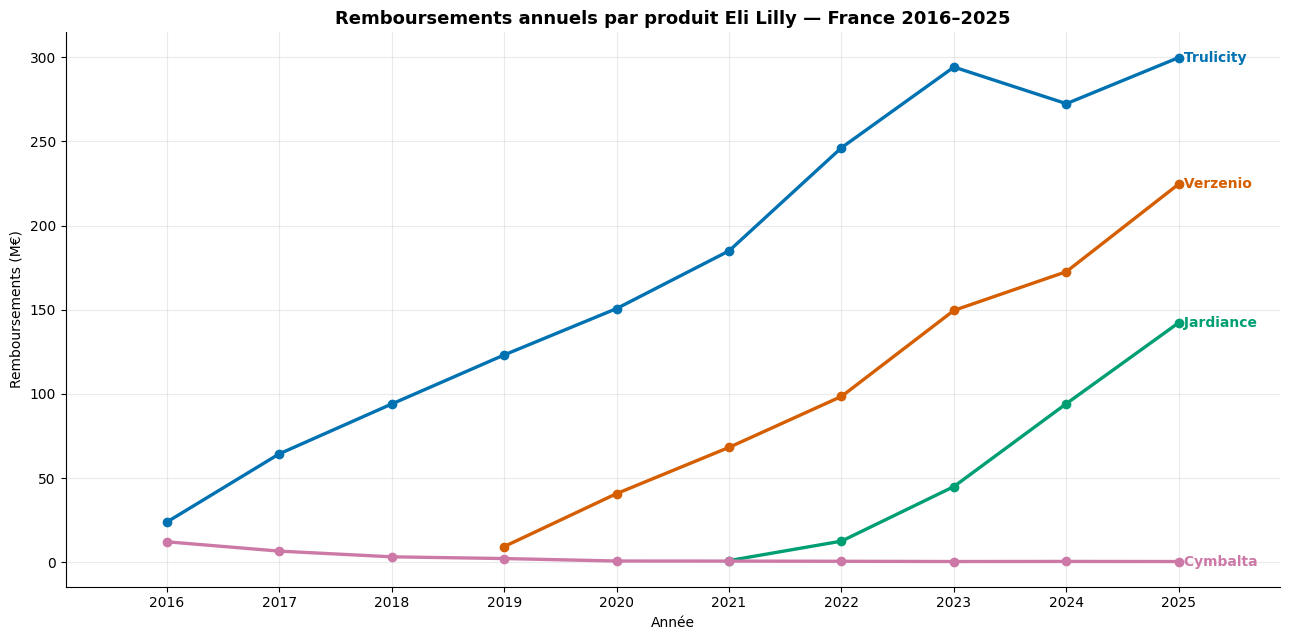

In [3]:
evo = (
    df.groupby(['annee', 'nom_lilly'])['rem'].sum()
    .unstack('nom_lilly').reindex(columns=ORDRE) / 1e6
)

fig, ax = plt.subplots(figsize=(13, 6.5))
for produit in ORDRE:
    serie = evo[produit].dropna()
    ax.plot(serie.index, serie.values, marker='o', markersize=6, linewidth=2.4,
            color=COULEURS[produit], label=produit)
    # Étiquette directe au bout de chaque courbe (pas de dépendance à la légende)
    x_last, y_last = serie.index[-1], serie.values[-1]
    ax.annotate(f' {produit}', (x_last, y_last), color=COULEURS[produit],
                fontsize=10, fontweight='bold', va='center')

ax.set_xticks(evo.index)
ax.set_xlabel('Année')
ax.set_ylabel('Remboursements (M€)')
ax.set_title("Remboursements annuels par produit Eli Lilly — France 2016–2025",
             fontsize=13, fontweight='bold')
ax.margins(x=0.10)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'trajectoires_produits.png', dpi=130, bbox_inches='tight')
plt.show()

**Lecture.** Trulicity domine et atteint un plateau vers 2023. Verzenio
(oncologie) et Jardiance montent en puissance et prennent le relais de la
croissance. Cymbalta, lui, s'est effondré après l'arrivée des génériques de
duloxétine — sa courbe est quasi plate au bas du graphique (analysée en détail
dans le notebook 02).

---
## 2. Deux façons de peser : le volume ou le prix

Un produit peut générer beaucoup de remboursements avec **un gros volume de boîtes
bon marché**, ou avec **peu de boîtes très chères**. Le coût moyen par boîte
(`rem / boites`) sépare ces deux modèles.

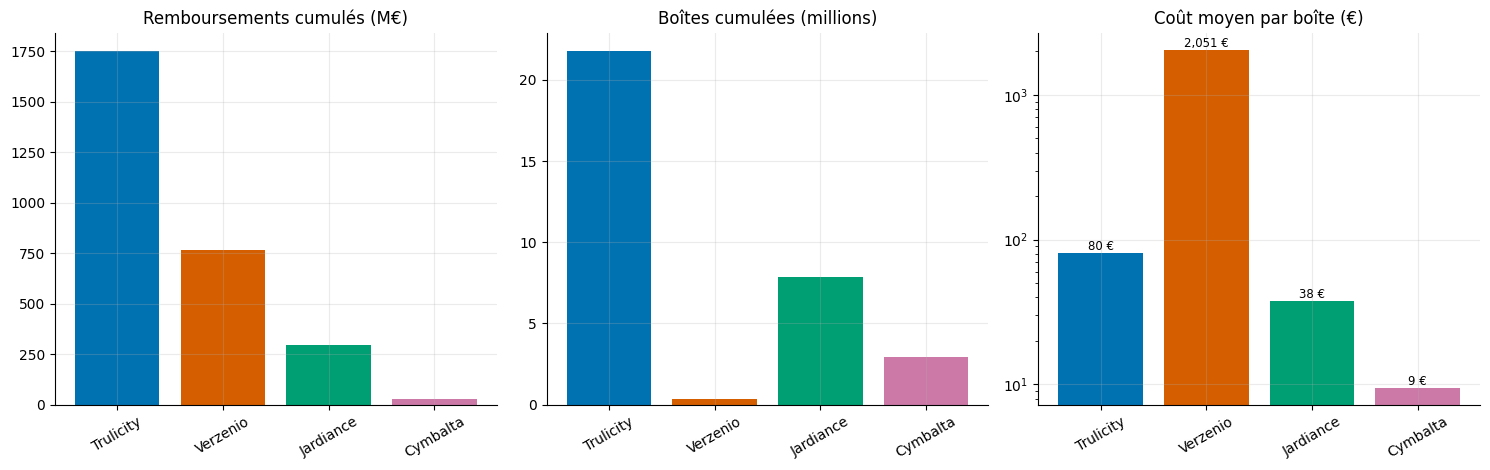

,Rem. cumulé (M€),Boîtes (M),Coût/boîte (€)
nom_lilly,,,
Trulicity,1754.1,21.81,80.0
Verzenio,764.0,0.37,2051.0
Jardiance,295.3,7.85,38.0
Cymbalta,28.0,2.95,9.0


In [4]:
profil = (
    df.groupby('nom_lilly')
    .agg(rem_total=('rem', 'sum'), boites_total=('boites', 'sum'))
    .reindex(ORDRE)
)
profil['cout_boite'] = profil['rem_total'] / profil['boites_total']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
couleurs_ordre = [COULEURS[p] for p in ORDRE]

axes[0].bar(ORDRE, profil['rem_total'] / 1e6, color=couleurs_ordre)
axes[0].set_title('Remboursements cumulés (M€)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(ORDRE, profil['boites_total'] / 1e6, color=couleurs_ordre)
axes[1].set_title('Boîtes cumulées (millions)')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(ORDRE, profil['cout_boite'], color=couleurs_ordre)
axes[2].set_title('Coût moyen par boîte (€)')
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=30)
for i, p in enumerate(ORDRE):
    axes[2].text(i, profil['cout_boite'][p], f"{profil['cout_boite'][p]:,.0f} €",
                 ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.show()

profil.assign(
    rem_total=lambda d: (d['rem_total'] / 1e6).round(1),
    boites_total=lambda d: (d['boites_total'] / 1e6).round(2),
    cout_boite=lambda d: d['cout_boite'].round(0),
).rename(columns={'rem_total': 'Rem. cumulé (M€)', 'boites_total': 'Boîtes (M)',
                  'cout_boite': 'Coût/boîte (€)'})

**Lecture.** Verzenio incarne le modèle **premium** : un coût par boîte de
plusieurs centaines d'euros (thérapie ciblée en oncologie) qui génère
d'énormes remboursements avec relativement peu de boîtes. Cymbalta est à
l'opposé : une boîte bon marché, d'autant plus après le passage au générique.
Trulicity et Jardiance occupent une position intermédiaire, typique des
traitements chroniques du diabète.

---
## 3. Décomposition de la croissance : prix ou volume ?

La hausse des remboursements d'un produit vient de deux sources :
plus de **boîtes** vendues (effet volume) ou un **prix par boîte** plus élevé
(effet prix). On décompose la variation totale entre la première et la dernière
année de chaque produit.

Pour une variation de $R = P \times Q$ (remboursement = prix × quantité), on
utilise la décomposition symétrique :
$$\Delta R = \underbrace{\overline{P}\,\Delta Q}_{\text{effet volume}} + \underbrace{\overline{Q}\,\Delta P}_{\text{effet prix}}$$
où $\overline{P}$ et $\overline{Q}$ sont les moyennes de début et de fin.

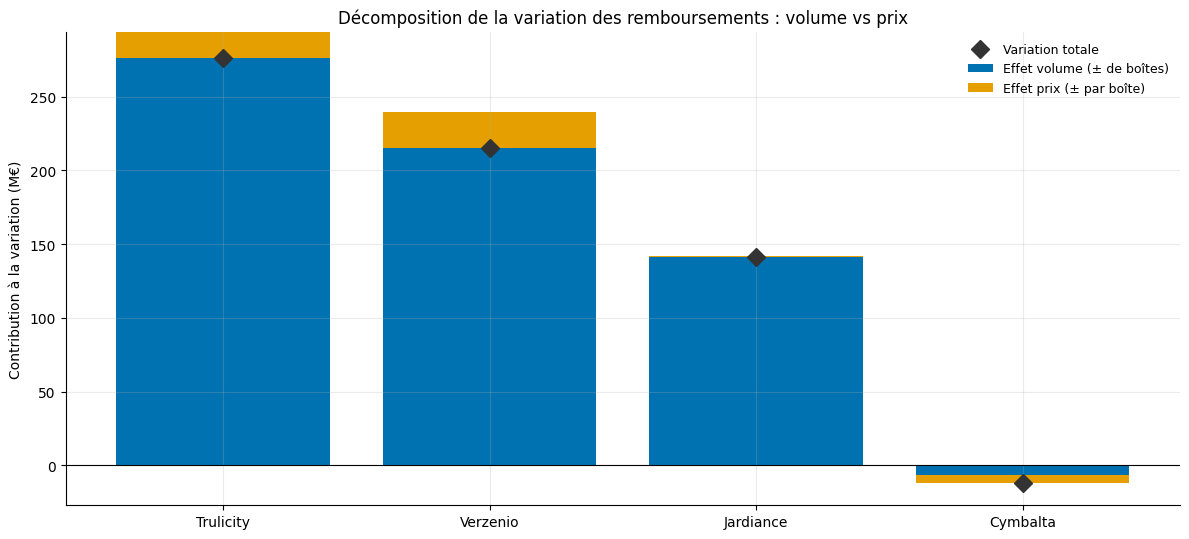

,annee_debut,annee_fin,Δ Rem (M€),dont volume (M€),dont prix (M€)
nom_lilly,,,,,
Trulicity,2016.0,2025.0,275.9,294.0,-18.1
Verzenio,2019.0,2025.0,215.4,239.8,-24.4
Jardiance,2021.0,2025.0,141.3,142.3,-0.9
Cymbalta,2016.0,2025.0,-11.7,-6.7,-5.1


In [5]:
def decompose(sub):
    """Décompose Delta(rem) en effet volume + effet prix entre 1re et dernière année."""
    g = sub.groupby('annee').agg(rem=('rem', 'sum'), q=('boites', 'sum'))
    g = g[g['q'] > 0]
    a0, a1 = g.index.min(), g.index.max()
    q0, q1 = g.loc[a0, 'q'], g.loc[a1, 'q']
    p0, p1 = g.loc[a0, 'rem'] / q0, g.loc[a1, 'rem'] / q1
    dQ, dP = q1 - q0, p1 - p0
    eff_vol   = (p0 + p1) / 2 * dQ
    eff_prix  = (q0 + q1) / 2 * dP
    return pd.Series({'annee_debut': a0, 'annee_fin': a1,
                      'delta_rem': g.loc[a1, 'rem'] - g.loc[a0, 'rem'],
                      'effet_volume': eff_vol, 'effet_prix': eff_prix})

decomp = df.groupby('nom_lilly').apply(decompose).reindex(ORDRE)

fig, ax = plt.subplots(figsize=(12, 5.5))
vol = decomp['effet_volume'] / 1e6
prix = decomp['effet_prix'] / 1e6
ax.bar(ORDRE, vol, color='#0072B2', label='Effet volume (± de boîtes)')
ax.bar(ORDRE, prix, bottom=vol, color='#E69F00', label='Effet prix (± par boîte)')
ax.plot(ORDRE, decomp['delta_rem'] / 1e6, 'D', color='#333333', markersize=9,
        label='Variation totale')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Contribution à la variation (M€)')
ax.set_title('Décomposition de la variation des remboursements : volume vs prix')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

decomp.assign(
    delta_rem=lambda d: (d['delta_rem'] / 1e6).round(1),
    effet_volume=lambda d: (d['effet_volume'] / 1e6).round(1),
    effet_prix=lambda d: (d['effet_prix'] / 1e6).round(1),
).rename(columns={'delta_rem': 'Δ Rem (M€)', 'effet_volume': 'dont volume (M€)',
                  'effet_prix': 'dont prix (M€)'})

**Lecture.** Pour les produits en croissance (Trulicity, Verzenio, Jardiance),
la hausse est portée avant tout par l'**effet volume** : la diffusion à de
nouveaux patients, pas une inflation du prix unitaire. Pour Cymbalta, la chute
combine effondrement du volume **et** baisse du prix par boîte (passage au tarif
générique) — la double peine du princeps.

---
## 4. Le renouvellement du portefeuille

Comment se recompose le portefeuille Lilly année après année ? La part de chaque
produit dans le total remboursé montre le **glissement** d'un mix dominé par le
diabète vers un mix où l'oncologie et les nouveaux traitements pèsent de plus en
plus.

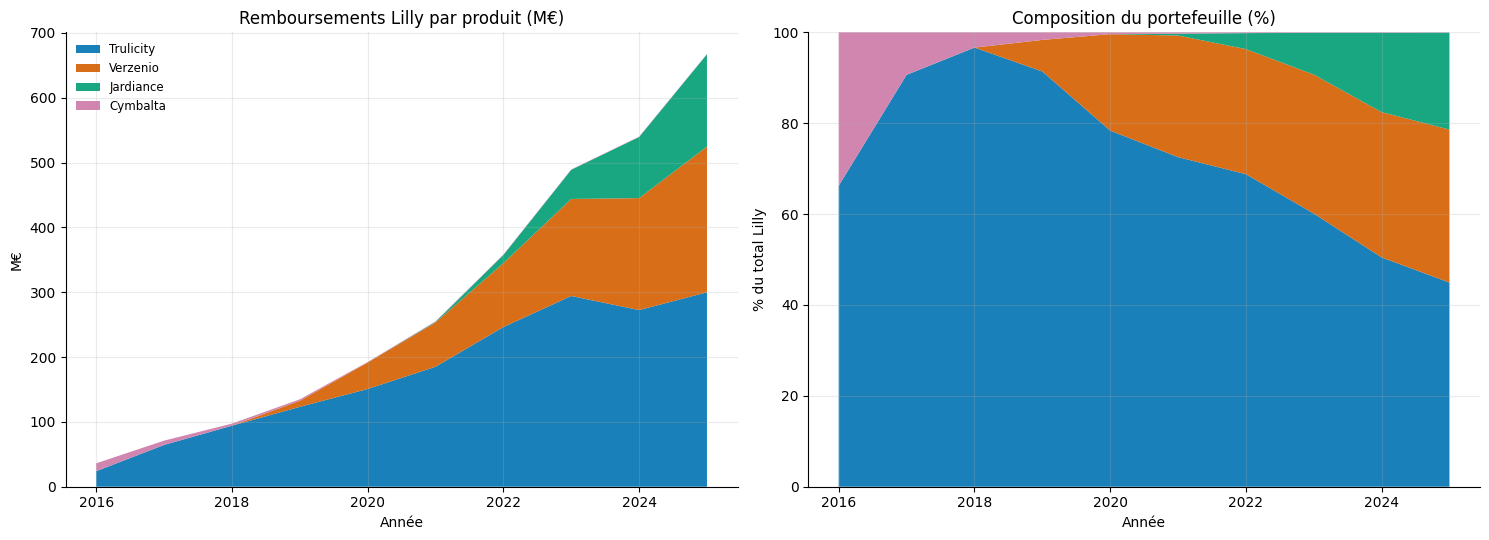

Part de chaque produit dans le total remboursé Lilly (%) :


nom_lilly,Trulicity,Verzenio,Jardiance,Cymbalta
annee,,,,
2016,66.2,0.0,0.0,33.8
2017,90.6,0.0,0.0,9.4
2018,96.6,0.0,0.0,3.4
2019,91.4,6.9,0.0,1.7
2020,78.4,21.2,0.0,0.4
2021,72.5,26.8,0.4,0.3
2022,68.8,27.5,3.5,0.2
2023,60.1,30.6,9.2,0.1
2024,50.5,32.0,17.5,0.1


In [6]:
mix = (
    df.groupby(['annee', 'nom_lilly'])['rem'].sum()
    .unstack('nom_lilly').reindex(columns=ORDRE).fillna(0) / 1e6
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Aire empilée en valeur absolue
axes[0].stackplot(mix.index, [mix[p] for p in ORDRE],
                  colors=[COULEURS[p] for p in ORDRE], labels=ORDRE, alpha=0.9)
axes[0].set_title('Remboursements Lilly par produit (M€)')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('M€')
axes[0].legend(loc='upper left', frameon=False, fontsize=8.5)
axes[0].set_xticks(mix.index[::2])

# Part relative (100 %)
part = mix.div(mix.sum(axis=1), axis=0) * 100
axes[1].stackplot(part.index, [part[p] for p in ORDRE],
                  colors=[COULEURS[p] for p in ORDRE], labels=ORDRE, alpha=0.9)
axes[1].set_title('Composition du portefeuille (%)')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('% du total Lilly')
axes[1].set_ylim(0, 100)
axes[1].set_xticks(part.index[::2])

plt.tight_layout()
plt.show()

print('Part de chaque produit dans le total remboursé Lilly (%) :')
part.round(1)

**Lecture.** Trulicity reste la locomotive, mais sa part relative recule à mesure
que Verzenio et Jardiance montent. Le portefeuille se **diversifie** et se
**déplace vers le premium** : c'est exactement ce qu'on attend d'un laboratoire
qui gère l'arrivée à maturité de son produit phare.

---
## 5. Synthèse et export

**Ce qu'il faut retenir :**
- Les quatre produits couvrent les quatre phases du cycle de vie, du lancement
  (Jardiance) au déclin post-générique (Cymbalta).
- La croissance vient du **volume** (diffusion), pas de l'inflation des prix.
- Verzenio illustre le basculement du portefeuille vers des thérapies à **prix
  unitaire élevé** (oncologie).
- Le portefeuille se **renouvelle** : les nouveaux produits prennent le relais du
  produit phare qui plafonne.

La table de synthèse produit × année est exportée pour les notebooks suivants.

In [7]:
synthese = (
    df.groupby(['nom_lilly', 'annee'])
    .agg(rem=('rem', 'sum'), boites=('boites', 'sum'), bse=('bse', 'sum'))
    .reset_index()
)
synthese['cout_boite'] = (synthese['rem'] / synthese['boites']).round(2)
synthese['taux_remb_pct'] = (synthese['rem'] / synthese['bse'] * 100).round(1)

export_path = OUTPUTS_DIR / 'cycle_vie_produits.csv'
synthese.to_csv(export_path, index=False, encoding='utf-8')
print(f'Exporté : {export_path} ({synthese.shape[0]} lignes)')
synthese.head(10)

Exporté : c:\Users\Enes\Desktop\projet_lilly\outputs\cycle_vie_produits.csv (32 lignes)


,nom_lilly,annee,rem,boites,bse,cout_boite,taux_remb_pct
0,Cymbalta,2016,12197916.45,844535,14795831.31,14.44,82.4
1,Cymbalta,2017,6656894.88,499646,8008060.85,13.32,83.1
2,Cymbalta,2018,3269003.33,415250,3919848.85,7.87,83.4
3,Cymbalta,2019,2245043.68,367542,2684850.30,6.11,83.6
4,Cymbalta,2020,783140.21,154801,944882.95,5.06,82.9
5,Cymbalta,2021,734162.40,147028,882154.11,4.99,83.2
6,Cymbalta,2022,625298.37,137519,749843.61,4.55,83.4
7,Cymbalta,2023,477686.03,130270,576036.38,3.67,82.9
8,Cymbalta,2024,536669.69,132794,645142.37,4.04,83.2
9,Cymbalta,2025,478021.27,121014,574711.84,3.95,83.2
